In [1]:
import logging

logFileName='Lx'

logger = logging.getLogger(logFileName)  

logFile= logFileName+'.log' 

loglevel = logging.DEBUG
logging.basicConfig(filename=logFile
                        ,filemode='w'
                        ,level=loglevel
                        ,format="%(asctime)s ; %(name)-60s ; %(levelname)-7s ; %(message)s")    

fileHandler = logging.FileHandler(logFile)     

logger.addHandler(fileHandler)

consoleHandler = logging.StreamHandler()
consoleHandler.setFormatter(logging.Formatter("%(levelname)-7s ; %(message)s"))
consoleHandler.setLevel(logging.INFO)
logger.addHandler(consoleHandler)

In [2]:
import pandas as pd
import time
import re
import glob

In [3]:
pd.set_option('display.max_rows',1111)
pd.set_option('display.max_colwidth', 111)
pd.set_option('display.max_columns', None)

In [4]:
import Lx
# from PT3S import Lx

## Beispieldaten

In [5]:
zip7File=r'c:\Users\wolters\source\repos\PT3S\testdata\Lx\20201113_151238a - 6 Logs.7z'
logFile=r'c:\Users\wolters\source\repos\PT3S\testdata\Lx\20201113_0000003.log'
zip7FilesDir=r'C:\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips'
#zip7File2=r'C:\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238a.7z'

## Initialisierung mit Zips
#### es werden nur die ersten und letzten Logs pro Zip angelesen und dort auch nur die erste und letzte Zeile (deswegen mit DictReader); zum Anlesen extrahierte Logs werden wieder geloescht wenn sie nicht existierten

In [6]:
start = time.time()
lx=Lx.AppLog(zip7Files=glob.glob(zip7FilesDir+r'\*.7z'))
end = time.time()
print(end - start)

113.25616383552551


In [7]:
lx.lookUpDf

,zipName,logName,FirstTime,LastTime
0,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000004.log,2020-11-13 14:24:54.973,2020-11-13 14:28:56.953
1,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000401.log,2020-11-14 16:34:26.229,2020-11-14 16:38:18.084
2,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000402.log,2020-11-14 16:38:18.083,2020-11-14 16:42:09.938
3,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000403.log,2020-11-14 16:42:09.936,2020-11-14 16:46:01.789
4,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000404.log,2020-11-14 16:46:01.788,2020-11-14 16:49:53.662
5,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000802.log,2020-11-15 18:45:50.678,2020-11-15 18:49:42.568
6,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000803.log,2020-11-15 18:49:42.566,2020-11-15 18:53:34.432
7,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0000804.log,2020-11-15 18:53:34.431,2020-11-15 18:57:26.344
8,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0001202.log,2020-11-16 20:33:54.776,2020-11-16 20:37:46.594
9,..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20...,20201113_0001203.log,2020-11-16 20:37:46.593,2020-11-16 20:41:38.485


In [8]:
lx.lookUpDfZips

,FirstTime,LastTime,TimespanPerLog,NumOfFiles,minFileNr,maxFileNr
zipName,,,,,,
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238a.7z,2020-11-13 14:24:54.973,2020-11-14 16:42:09.938,0 days 00:03:57.776293969,398,4,402
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238b.7z,2020-11-14 16:42:09.936,2020-11-15 18:49:42.568,0 days 00:03:55.720882205,399,403,802
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238c.7z,2020-11-15 18:49:42.566,2020-11-16 20:37:46.594,0 days 00:03:52.792050125,399,803,1202
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238d.7z,2020-11-16 20:37:46.593,2020-11-17 22:46:04.738,0 days 00:03:55.834949874,399,1203,1602
..\..\..\..\..\3s\Projekte\20.278 - Actemium FBG Nachtrag 1\04 - Logdateien\20201113_151238\Wol\Log7Zips\20201113_151238e.7z,2020-11-17 22:46:04.736,2020-11-18 07:14:58.532,0 days 00:03:42.874423357,137,1603,1740


In [9]:
timeStart='2020-11-13 14:24:55'
timeEnd='2020-11-13 14:24:59'
df=lx.getFromZips(timeStart=timeStart,timeEnd=timeEnd)

In [11]:
df.head()

,#LogTime,LogLevel,SubSystem,Direction,ProcessTime,ID,Value,ScenTime,State,Remark
0,2020-11-13 14:24:54.973,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Logfilesize of /home/3sconsult/Logs/20201113_151238/20201113_0000003.log is 102964523
1,2020-11-13 14:24:54.975,STD,LOGGING,nan,NaT,nan,NaN,2020-11-13 15:24:52,nan,Free space in Log Directory: 195155144704
2,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Starting cycle for 2020-11-13 15:24:53.000
3,2020-11-13 14:24:55.000,INF,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Updating DFIDTs...
4,2020-11-13 14:24:55.027,STD,SQC,nan,NaT,nan,NaN,2020-11-13 15:24:53,nan,Status is 0


In [13]:
TCsdfOPC,TCsLDSIn,TCsLDSRes,TCsSirCalc=lx.getTCsFromDf(df)

In [14]:
TCsdfOPC.head()

ID,Objects.3S_STEUERUNG.3S_APP_LDS.In.LIFE,Objects.FBGL_LECK_SEG_NAME.L_6_FUD_25_BHD.SEG.RICHT.S,Objects.FBG_ESCHIEBER.6_BHD_25_MOV_07.In.ZUST,Objects.FBG_ESCHIEBER.6_ESX_25_MOV_02.In.ZUST,Objects.FBG_ESCHIEBER.6_FTV_25_MOV_04.In.ZUST,Objects.FBG_ESCHIEBER.6_FUD_25_MOV_01.In.ZUST,Objects.FBG_ESCHIEBER.6_HCX_25_MOV_06.In.ZUST,Objects.FBG_ESCHIEBER.6_WPX_25_MOV_03.In.ZUST,Objects.FBG_ESCHIEBER.7_AL1_51_MOV_100.In.ZUST,Objects.FBG_HPS.8_HND_03_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_BHD_20_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BHD_25_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BHD_26_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_BID_10_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_FUD_25_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_KED_43_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_LPA_42_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_LSX_43_PTI_01.In.MW.value,Objects.FBG_HPS_M.6_OHN_41_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.6_ZW1_20_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.7_AL1_51_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_ALD_44_PTI_01_E.In.MW.value,Objects.FBG_HPS_M.7_SPV_44_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_URX_44_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_WAA_51_PTI_01.In.MW.value,Objects.FBG_HPS_M.7_WSR_52_PTI_01.In.MW.value,Objects.FBG_MESSW.3_WAV_43_FT_01.In.MW.value,Objects.FBG_MESSW.6_BHD_20_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_22_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_25_FT_01.In.MW.value,Objects.FBG_MESSW.6_BHD_25_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BHD_26_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_01_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_09_TT_Z.In.MW.value,Objects.FBG_MESSW.6_BID_10_FT_01.In.MW.value,Objects.FBG_MESSW.6_BID_10_TT_01.In.MW.value,Objects.FBG_MESSW.6_BUV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_DIV_07_TT_01.In.MW.value,Objects.FBG_MESSW.6_EPX_23_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ESX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_FTV_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_FUD_03_TT_Z.In.MW.value,Objects.FBG_MESSW.6_FUD_25_FT_01.In.MW.value,Objects.FBG_MESSW.6_FUD_25_TT_Z.In.MW.value,Objects.FBG_MESSW.6_GHV_03_FT_02.In.MW.value,Objects.FBG_MESSW.6_GHV_03_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HCX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_HSV_20_PTI_01.In.MW.value,Objects.FBG_MESSW.6_KED_26_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_39_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_43_FT_01.In.MW.value,Objects.FBG_MESSW.6_KED_L1_PTI_01.In.MW.value,Objects.FBG_MESSW.6_KED_L1_PTI_03.In.MW.value,Objects.FBG_MESSW.6_KED_L1_TT_Z.In.MW.value,Objects.FBG_MESSW.6_KED_L2_PTI_04.In.MW.value,Objects.FBG_MESSW.6_KED_L2_TT_Z.In.MW.value,Objects.FBG_MESSW.6_LSX_43_PTI_03.In.MW.value,Objects.FBG_MESSW.6_MGX_40_PTI_01.In.MW.value,Objects.FBG_MESSW.6_MHV_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_MOV_01_PTI_02.In.MW.value,Objects.FBG_MESSW.6_NGD_46_TT_01.In.MW.value,Objects.FBG_MESSW.6_OEV_39_PTI_01.In.MW.value,Objects.FBG_MESSW.6_PIV_20_PTI_01.In.MW.value,Objects.FBG_MESSW.6_PSD_03_FT_01.In.MW.value,Objects.FBG_MESSW.6_PSD_03_TT_Z.In.MW.value,Objects.FBG_MESSW.6_PSD_04_TT_Z.In.MW.value,Objects.FBG_MESSW.6_PSD_05_TT_Z.In.MW.value,Objects.FBG_MESSW.6_RGV_08_TT_01.In.MW.value,Objects.FBG_MESSW.6_ROV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_RTX_40_PTI_01.In.MW.value,Objects.FBG_MESSW.6_SNV_26_PTI_01.In.MW.value,Objects.FBG_MESSW.6_SPV_01_PTI_01.In.MW.value,Objects.FBG_MESSW.6_STX_41_PTI_01.In.MW.value,Objects.FBG_MESSW.6_SWV_42_PTI_02.In.MW.value,Objects.FBG_MESSW.6_TUD_40_FT_02.In.MW.value,Objects.FBG_MESSW.6_WPX_25_PTI_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_01_FT_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_01_TT_Z.In.MW.value,Objects.FBG_MESSW.6_ZW1_07_TT_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_08_TT_01.In.MW.value,Objects.FBG_MESSW.6_ZW1_20_TT_Z.In.MW.value,Objects.FBG_MESSW.7_HKV_50_PTI_01.In.MW.value,Objects.FBG_MESSW.7_SPV_44_PTI_02.In.MW.value,Objects.FBG_MESSW.7_URX_44_PTI_03.In.MW.value,Objects.FBG_MESSW.7_URX_52_PTI_01.In.MW.value,Objects.FBG_MESSW.7_WU1_23_TT_01.In.MW.value,Objects.FBG_MESSW.8_HNA_03_P

<AxesSubplot:xlabel='ProcessTime'>

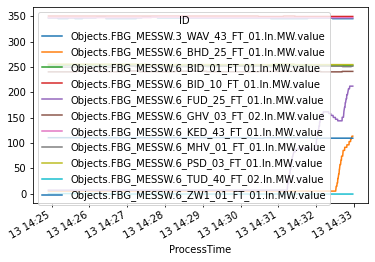

In [15]:
regExpFT=Lx.pID.pattern.replace('(?P<C4>[a-z,A-Z,0-9]+)','FT')
TCsdfOPC.filter(regex=regExpFT, axis=1).plot()

### mit Log

In [ ]:
start = time.time()
lx=Lx.AppLog(logFile=logFile) # init with single log
end = time.time()
print(end - start)

In [ ]:
start = time.time()
lx=Lx.AppLog(logFile=logFile,readWithDictReader=True,nRows=1) # init with single log
end = time.time()
print(end - start)

### mit Zip (d.h. mit 1. Log in Zip)

In [ ]:
start = time.time()
lx=Lx.AppLog(zip7File=zip7File) # init with 1st Log in zip
end = time.time()
print(end - start)

In [ ]:
start = time.time()
lx=Lx.AppLog(zip7File=zip7File,readWithDictReader=True,nRows=1) # init with 1st Log in zip
end = time.time()
print(end - start)

## mit Daten befuellen

### aus zip

In [ ]:
start = time.time()
lx.addZip7File(zip7File,firstAndLastLogOnly=True) # data from zip
end = time.time()
dauer=end - start

In [ ]:
print("6 logs benoetigen {!s:s} Sekunden".format(round(dauer,2)))
dauer400LogsinMinuten=round(dauer/6*400/60,2) # in einer Zip sind bei 1 GB ca. 400 Logs
print("400 logs benoetigen dann ca. {!s:s} Minuten".format(dauer400LogsinMinuten))
KalenderZeitProLogInMinuten=3.5 # Mittelwert
KalenderZeit400Logs=400*KalenderZeitProLogInMinuten
f=KalenderZeit400Logs/dauer400LogsinMinuten
print("Logs für 1 Kalendertag benoetigen dann in der Aufbereitung ca. {!s:s} Stunde(n)".format(round(24*60/f/60),2))

In [ ]:
lx.lookUpDf

In [ ]:
m=re.search('([0-9]+)_([0-9]+)(\.log)','20201113_0000004.log')
int(m.group(2))

In [ ]:
g=lx.lookUpDf.groupby(by='zipName')
gdf=g.agg(['min', 'max'])
#g.agg({'FirstTime': ['min',], 'C': 'sum'})
gdf

In [ ]:
minTime=gdf.loc[:,('FirstTime','min')]
maxTime=gdf.loc[:,('LastTime','max')]
maxTime-minTime

In [ ]:
minFileNr=gdf.loc[:,('Name','min')].apply(lambda x: int(re.search('([0-9]+)_([0-9]+)(\.log)',x).group(2)))
maxFileNr=gdf.loc[:,('Name','max')].apply(lambda x: int(re.search('([0-9]+)_([0-9]+)(\.log)',x).group(2)))
maxFileNr-minFileNr

In [ ]:
s=(maxTime-minTime)/(maxFileNr-minFileNr)
s

In [ ]:
dfZip=s.to_frame().rename(columns={0:'dT'})
dfZip

In [ ]:
dfZip['NumOfFiles']=maxFileNr-minFileNr
dfZip

## aus mehreren Zips

In [ ]:
zips=glob.glob(zip7FilesDir+r'\*.7z')

In [ ]:
lx.addZip7Files(zips,firstAndLastLogOnly=True) # data from zip

In [ ]:
lx.lookUpDfZips

In [ ]:
# 20201113_0000004.log

"{:07d}".format(402)

In [ ]:
 for zipFile in lx.lookUpDfZips.index:
                print(zipFile)

In [ ]:
for index, row in lx.lookUpDfZips.iterrows():
    print(row['NumOfFiles'])
    print(index)
    print(row)
    pass

In [ ]:
row['TimespanPerLog'].seconds

In [ ]:
ts=row['FirstTime']-pd.Timestamp('2020-11-13 14:24:54.973')

In [ ]:
ts.seconds

In [ ]:
dir(row['FirstTime'])

## Daten extrahieren

In [ ]:
start = time.time()
df=lx.get() # data from zip - ohne Parameter alles; das ist i.d.R. viel zu viel fuer den Arbeitsspeicher
end = time.time()
dauer=end - start
print(dauer)

In [ ]:
print("eine Kalenderzeit von {!s:s} Minuten benoetigt {!s:s} Minuten zum lesen".format(KalenderZeitProLogInMinuten*6,round(dauer/60,2)))
print("eine typische Analyse-Kalenderzeit von 30 Minuten benoetigt dann {!s:s} Minuten zum lesen".format(round(30*dauer/60/(KalenderZeitProLogInMinuten*6),2)))

In [ ]:
df.head()

In [ ]:
df.tail()

## Initialisierung mit H5

In [ ]:
h5File=r'C:\Users\wolters\source\repos\PT3S\testdata\Lx\Log ab 2020 11 13 14 24 54.973000.h5'

In [ ]:
start = time.time()
lx=Lx.AppLog(h5File=h5File) # init with H5 (init by "connection" to previuosly parsed Logs)
end = time.time()
print(end - start)

In [ ]:
lx.lookUpDf

In [ ]:
df=lx.get(timeStart='2020-11-13 14:28:57') 
df=lx.get(timeEnd='2020-11-14 16:38:00') 
df=lx.get(timeStart='2020-11-13 14:28:57',timeEnd='2020-11-14 16:38:00') 

In [ ]:
df=lx.get() # data from zip - ohne Parameter alles; das ist i.d.R. viel zu viel fuer den Arbeitsspeicher

In [ ]:
df.head()

## Zeitreihen

In [ ]:
TCsdfOPC,TCsLDSIn,TCsLDSRes,TCsSirCalc=lx.getTcsFromDf(df)

In [ ]:
TCsdfOPC.head()

In [ ]:
regExpFT=Lx.pID.pattern.replace('(?P<C4>[a-z,A-Z,0-9]+)','FT')
TCsdfOPC.filter(regex=regExpFT, axis=1).plot(xlim=('2020-11-13 14:28:56','2020-11-13 14:37:02'))